<a href="https://colab.research.google.com/drive/1mpSUNfBN5_dItEz5NWUks--WIQDx1mN5" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9 - Multi Layer Perceptron, MLP - Homework by Łukasz Grzegrzółka

### Notebook author: Szymon Nowakowski


# Presentation on Tensors and Linear Layers
--------------------

We shall start off by going through a [short presentation on tensors and linear layers](https://github.com/SzymonNowakowski/Machine-Learning-2025/blob/master/tensors_and_linear_layers.pdf). It is best to first download it and then go through it in a slide-show layout.

## Note on Previous Class Code and Broadcasting

We encountered broadcasting in our previous class session:



In [ ]:
import torch

N = 100
focus1 = torch.tensor([-2.0, 0.0])             # First focus,                        sized (2)
points = torch.rand((N, 2)) * 10 - 5           # Uniformly distributed in [-5, 5]    sized (N, 2)

############### when we computed distances to focal points ##############################
dist1 = torch.norm(points - focus1, dim=1)     # the focus 1 gets expanded to (1, 2) then broadcasted to (N, 2)
                                               # to match the points tensor

                                               # effectively what happens is that
                                               # the focus point gets substracted from every other point

                                               # also: note how natural this notation feels here

############### when we computed pairwise point-to-point distances #####################
# Compute all pairwise distances in parallel
print(points.unsqueeze(1).size())                   # sized: (N, 1, 2)
print(points.unsqueeze(0).size())                   # sized: (1, N, 2)

diffs = points.unsqueeze(1) - points.unsqueeze(0)   # sized: (N, N, 2) because of broadcasting
distances = torch.norm(diffs, dim=-1)               # sized: (N, N)

print(distances.size())                             # N x N


torch.Size([100, 1, 2])
torch.Size([1, 100, 2])
torch.Size([100, 100])


# Multi Layer Perceptron (MLP) Diagram
------------------

![network diagram](https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025/refs/heads/master/MLP_diagram.jpg)

# Task
-------------------

A nonlinear component in-between the linear layers is essential. Why?

# A Non-Linearity
---------------------

$$
l_{i+1} = f(W \cdot l_i),
$$
with $f$ being a sigmoid $f(\cdot)=\sigma(\cdot)$, hiperbolic tangent $f(\cdot)=\tanh(\cdot)$ or a Rectified Linear Unit (ReLU) $f(\cdot)=[\cdot]_+$ (taking the positive part).

The **sigmoid function** is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

It maps any input $x$ to the range $(0,1)$, making it useful for probabilistic interpretations and smooth gradient updates. However, it can suffer from vanishing gradients for large positive or negative inputs.

The **hyperbolic tangent (tanh) function** is defined as:

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

It maps any input $x$ to the range $(-1,1)$, making it **zero-centered**, which can help with optimization compared to the sigmoid function.

Alternatively, **tanh** can be expressed as a **scaled sigmoid**:

$$
\tanh(x) = 2\sigma(2x) - 1
$$

This shows that **tanh** is just a stretched and shifted version of **sigmoid**, allowing for stronger gradients in the middle range and reducing saturation effects compared to sigmoid.


As we said, a non-linear component is essential:
1. without it, a compostion of linear components would be just a linear component, so a multilayer network would be equivalent to a single layered network.
2. it is a nonlinear component that enables a neural network to express nonlinear functions, too.




# MNIST dataset
----------------------

In this workshop, we will construct an MLP network designed to a specific task of classification of MNIST dataset: a set of handwritten digits from *zero* to *nine*. MNIST stands for Modified National Institute of Standards and Technology database.

**You can read more about this dataset [here](https://colah.github.io/posts/2014-10-Visualizing-MNIST/#MNIST).**




# Multi Layer Perceptron Notation
---------------------------------

In this workshop we will be classifying 28 by 28 images into 10 classes. Thus, a four layer perceptron (our classificator) we will work further with can be defined as
$\hat f:\mathbb{R}^{28\cdot 28} \rightarrow \mathbb{R}^{10}$ defined as

$$\hat f \left(x; W_1, W_2, W_3, W_4, b_1, b_2, b_3, b_4 \right) =  W_4 \left[ W_3 \left[ W_2 \left[ W_1 x  + b_1 \right]_+  + b_2 \right]_+  + b_3 \right]_+ + b_4,$$

where matrices $W_1, \ldots, W_4$ are tensors of order two (matrices) with matching dimensions and bias terms $b_1, \ldots, b_4$ are tensors of order one (vectors) of matching dimensions, and we are using ReLU activation.

Note, that there is no nonlinear activation after the last layer in our neural network. **There is an implicit softmax applied while cross entropy loss is calculated by `torch.nn.functional`.**


# Reading MNIST Dataset to Play with It
--------------------

In [ ]:
import torch
import torchvision
from matplotlib import pyplot

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=None)

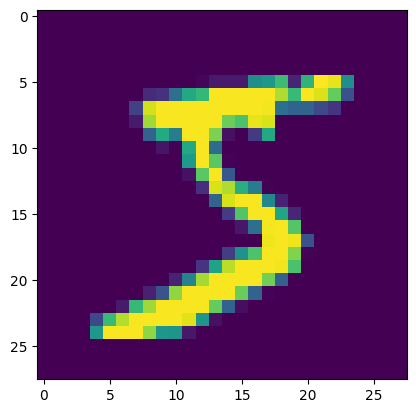

In [ ]:
train_image, train_target = trainset[0]    #let us examine the 0-th sample
pyplot.imshow(train_image)
pyplot.show()

In [ ]:
trainset.data[0]     #it will be shown in two rows, so a human has hard time classificating it

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [ ]:
trainset[0][1]    #check if you classified it correctly in your mind

5

# Rereading the MNIST Data (Serious Preparation for Training)
------------------

In [ ]:
(trainset.data.numpy().mean()/255.0, trainset.data.numpy().std()/255.0)   #MNIST datapoints are RGB integers 0-255

(np.float64(0.1306604762738429), np.float64(0.30810780385646264))

# Task
---------------

Why do we need to normalize the data, and not feed the NN with the 0-255 integers?

In [ ]:
transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

## Visualizing Data


### Labels (Ground Truth Outputs)

In [ ]:
for i, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        if i<5:
            print(i, "-th batch labels :", batch_labels)

0 -th batch labels : tensor([7, 1, 5,  ..., 4, 0, 9])
1 -th batch labels : tensor([5, 7, 2,  ..., 0, 0, 0])
2 -th batch labels : tensor([4, 4, 1,  ..., 5, 3, 2])
3 -th batch labels : tensor([6, 7, 4,  ..., 4, 4, 0])
4 -th batch labels : tensor([7, 3, 0,  ..., 5, 7, 7])


A single label is an entity of order zero (a constant), but batched labels are of order one. The first (and only) index is a sample index within a batch.

### Inputs

In [ ]:
for i, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        if i==0:
            print(i, "-th batch inputs :", batch_inputs)

0 -th batch inputs : tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
     

OK, so each data image was initially a two dimensional image when we first saw it, but now the batches have order 4. The first index is a sample index within a batch, but a second index is always 0. This index represents a Channel number inserted here by `ToTensor()` transformation, always 0. As this order is one-dimensional, we can get rid of it, later, in training, in `Flatten` layer or by using `squeeze()` on a tensor.

# MLP Definition
-----------------

Your job now is to take the (fully functional) definition of the MLP structure and get rid off the Sequential layer.


In [ ]:
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = torch.nn.Sequential(   #Sequential is a structure which allows stacking layers one on another in such a way,
                                          #that output from a preceding layer serves as input to the next layer
            torch.nn.Flatten(),   #change the last three orders in data (with dimensions 1, 28 and 28 respectively) into one order of dimensions (1*28*28)
            torch.nn.Linear(1*28*28, 1024),  #which is used as INPUT to the first Linear layer
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),   #IMPORTANT! Please observe, that the OUTPUT dimension of a preceding layer is always equal to the INPUT dimension of the next layer.
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 256),
            torch.nn.ReLU(),            #ReLU (or a Sigmoid if you want) is a nonlinear function which is used in-between layers
            torch.nn.Linear(256, 10),
        )
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):
        x = self.mlp(x)
        x = self.dropout(x)
        return x

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = torch.nn.ReLU()                   # we need only one ReLU instance, because ReLU has no parameters.
        self.flatten = torch.nn.Flatten()
        self.linear1 = torch.nn.Linear(1*28*28, 1024) # this is the first Linear layer
        self.linear2 = torch.nn.Linear(1024, 2048) # this is the second Linear layer
        self.linear3 = torch.nn.Linear(2048, 256) # this is the third Linear layer
        self.linear4 = torch.nn.Linear(256, 10) # this is the fourth Linear layer
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):      # B, 1, 28, 28
        x = self.flatten(x)    # B, 784
        x = self.linear1(x)    # B, 1024
        x = self.relu(x)       # B, 1024
        x = self.linear2(x)    # B, 2048
        x = self.relu(x)       # B, 2084
        x = self.linear3(x)    # B, 256
        x = self.relu(x)       # B, 256
        x = self.linear4(x)    # B, 10

        x = self.dropout(x)
        return x

# Training Loop
----------------------

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = MLP().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing training
for epoch in range(8):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        #batch_inputs.squeeze(1)     #alternatively if not for a Flatten layer, squeeze() could be used to remove the second order of the tensor, the Channel, which is one-dimensional (this index can be equal to 0 only)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the MLP object. Please note, that the last layer of the MLP is linear
                                            #and MLP doesn't apply
                                            #the nonlinear activation after the last layer
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cuda
epoch: 0 batch: 0 current batch loss: 2.307645797729492
epoch: 0 batch: 1 current batch loss: 2.0917930603027344
epoch: 0 batch: 2 current batch loss: 1.6532524824142456
epoch: 0 batch: 3 current batch loss: 1.1098527908325195
epoch: 0 batch: 4 current batch loss: 0.9033687114715576
epoch: 0 batch: 5 current batch loss: 1.3059382438659668
epoch: 0 batch: 6 current batch loss: 1.0466101169586182
epoch: 0 batch: 7 current batch loss: 1.0174158811569214
epoch: 0 batch: 8 current batch loss: 0.9283682107925415
epoch: 0 batch: 9 current batch loss: 0.6680020093917847
epoch: 0 batch: 10 current batch loss: 0.6456937789916992
epoch: 0 batch: 11 current batch loss: 0.6050190925598145
epoch: 0 batch: 12 current batch loss: 0.622737467288971
epoch: 0 batch: 13 current batch loss: 0.5669562816619873
epoch: 0 batch: 14 current batch loss: 0.5411897897720337
epoch: 0 batch: 15 current batch loss: 0.5216403007507324
epoch: 0 batch: 16 current batch loss: 0.48558616638183594
epoch: 0 

# Testing
----------------------

Correct the code below so it works.

In [ ]:
good = 0
wrong = 0

net.eval()              #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing evaluation
with torch.no_grad():   #it prevents that the net learns during evalution. The gradients are not computed, so this makes it faster, too
    for batch, data in enumerate(testloader): #batches in test are of size 1
        datapoint, label = data

        ########## Treatment:
        datapoint = datapoint.to(device)
        label = label.to(device)
        #########

        prediction = net(datapoint)                  #prediction has values representing the "prevalence" of the corresponding class
        classification = torch.argmax(prediction)    #the class is the index of maximal "prevalence"

        if classification.item() == label.item():
            good += 1
        else:
            wrong += 1

print("accuracy = ", good/(good+wrong))

accuracy =  0.9802


# **Homework Assignment - *Do Androids Dream of Electric Sheep?***

-------------------------------------  

"Do Androids Dream of Electric Sheep?" – the famous title of Philip K. Dick’s novel – raises a fascinating question: if artificial intelligence could dream, what would it see?  

In this assignment, we explore a phenomenon known as **neural network dreams**, where instead of optimizing a neural network's weights, we **optimize the input itself** to achieve a desired classification outcome. Given a fully trained MNIST classification network, your goal is to manipulate its inputs so that it confidently predicts each digit from 0 to 9, starting from pure noise.  

## **Tasks Description**  

During this class we designed and trained a **MNIST classification neural network**, which takes a **batch of grayscale images** of size **$28 \times 28$** as input and outputs a probability distribution over the 10 digit classes (0–9). However, instead of using real MNIST images, you will **treat the input batch itself as a set of trainable parameters** and optimize it so that the network classifies each image as a specific digit.  

1. Your first task is to generate **a batch of 10 images**, where each image is
   classified as one of the digits **0, 1, 2, ..., 9**, starting from an initial batch of ten **random Gaussian noise images**.  

   Discuss the following question: do the generated images resemble real MNIST digits? Why or why not?  

2. Discuss, how you would approach a second task of generating an image that bares similarity to two or more digits simultaneously. **Implement your idea to see the results.**

3. Third task: repeat the previous tasks with an additional L2 penalty on noise within the images. Experiment with adding `lambda_l2 * dreamed_input_batch.pow(2).mean()` loss term, with `lambda_l2` being the penalty cooefficient within an exponential progression, say from 0.001 to 10.0. Are the new digits recognized correctly? How does the penalty impact the digit quality? Explain.

### **Optimization Process for Task 1**  

1. Start with a **batch of 10 random Gaussian noise images** as the initial input and $(0, 1, 2, \ldots, 9)$ as the expected output batch of target digits.  
2. Define the objective: maximize the neural network's confidence for the corresponding target digit for each image in the batch.  
3. Use **gradient descent** to modify the pixels in each image, making the network classify each one as the assigned digit.  
4. Repeat until the network assigns suffieciently high confidence to each image’s target class.  

### **Implementation Details**  

- The neural network weights **must remain frozen** during optimization. You are modifying only the input images.  
- The loss function should be the **cross-entropy loss** between the predicted probabilities and the desired class labels (plus an optional weighted L2 penalty regularizing the images in task 3).


## **Points to Note**  

1. **Visualize** the optimization process: Save images of the generated inputs at different steps and plot the classification confidence evolution over iterations.  
3. **Document your findings** and explain the behavior you observe.  

## **Task & Deliverables**  

- A **Colab notebook** containing solutions for both tasks:
  - The full implementation.
  - Visualizations of the generated batch of images.
  - A written explanation of your observations.
- **Bonus:** If you create an **animation** showing the evolution of the input images during optimization, it will be considered a strong enhancement to your submission.
  - You can generate an animation programmatically (e.g., using Matplotlib or OpenCV).
  - Or, save image frames and use external tools to create a video.
  - Provide a **link** to any video files in the README.
- Upload your notebook and results to your **GitHub repository** for the course.
- In the **README**, include a **link** to the notebook.
- In the notebook, include **“Open in Colab”** badge so it can be launched directly.




## Task 1 - Optimal input images

During this experiment, the neural network is no longer being trained in the usual sense. Its parameters are frozen, and the model is switched to evaluation mode, which means that none of its internal weights are updated. Instead, the only object being optimized is the input itself: a batch of ten images, each initialized as pure Gaussian noise. Every image in this batch is assigned a target label from 0 to 9, and gradient descent is used to modify the pixel values so that the network becomes increasingly confident that each noisy image corresponds to its designated digit. In other words, the optimization process pushes the input images in the direction that maximizes the activation of the output neuron associated with the chosen class. The network’s weights remain fixed throughout; only the pixels change.

What emerges from this process is a striking demonstration of how differently a neural network “sees” compared to a human observer. Even after hundreds or thousands of optimization steps, the resulting images do not resemble real MNIST digits. To a human, they remain chaotic patterns of noise with no recognizable structure. Yet the network assigns them classification probabilities extremely close to one hundred percent. This happens because the network is not attempting to generate realistic digits or meaningful shapes. Its objective is purely mathematical: to increase the output score for a particular class. The optimization therefore discovers pixel configurations that strongly activate specific internal features of the network, even if those configurations bear no resemblance to the kinds of images humans associate with handwritten digits.

This behavior highlights a fundamental difference between biological and artificial perception. Although artificial neural networks are loosely inspired by the structure of the brain, they do not interpret images in a human-like way. They respond to statistical patterns in the data that may be invisible or unintuitive to us. As a result, the model can be absolutely certain that a pattern of noise corresponds to a digit, even though no human would recognize it as such. The generated images therefore do not resemble real MNIST digits, because the optimization process is not constrained by human visual priors or semantic structure. It simply finds the most efficient route, in pixel space, to maximally activate the neuron corresponding to each class.

In [ ]:
import matplotlib.pyplot as plt

def show_dreams(images, logits, step):
    """
    images: tensor (10, 1, 28, 28) - po detach().cpu()
    logits: tensor (10, 10) - wyjście sieci, bez softmax
    step: numer iteracji
    """
    probs = torch.nn.functional.softmax(logits, dim=1).cpu()  # prawdopodobieństwa
    preds = probs.argmax(dim=1)             # przewidywane cyfry

    fig, axes = plt.subplots(1, images.shape[0], figsize=(18, 2.5))
    fig.suptitle(f"Step {step}", fontsize=16)

    for i in range(images.shape[0]):
        axes[i].imshow(images[i, 0], cmap="gray")
        axes[i].axis("off")

        pred_digit = preds[i].item()
        confidence = probs[i, pred_digit].item() * 100

        axes[i].set_title(f"{pred_digit}\n{confidence:.1f}%", fontsize=10)

    plt.show()

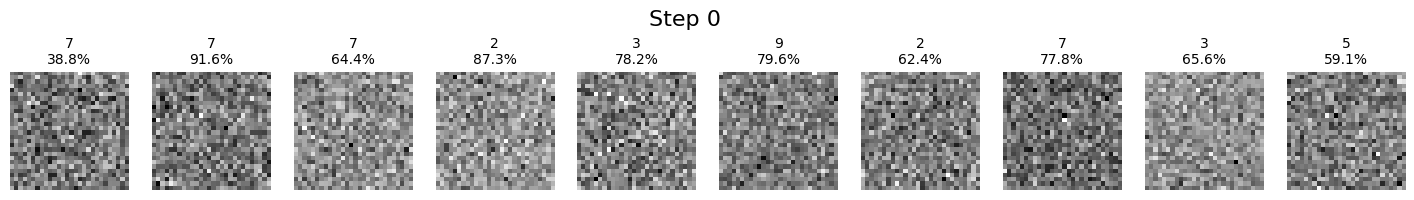

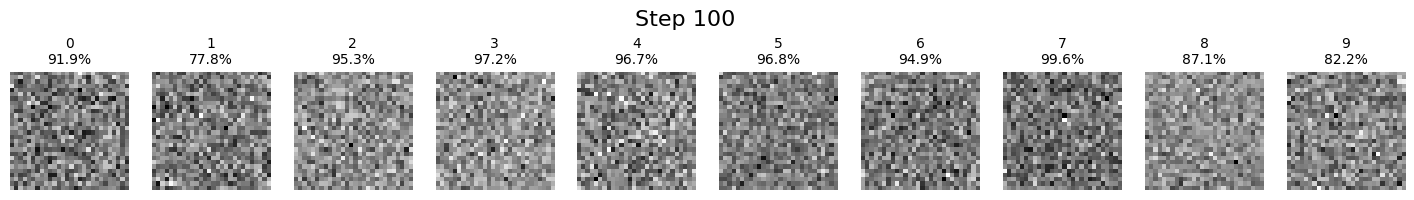

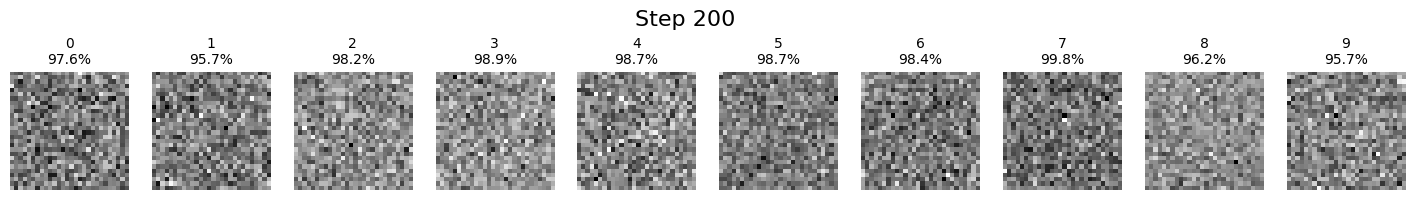

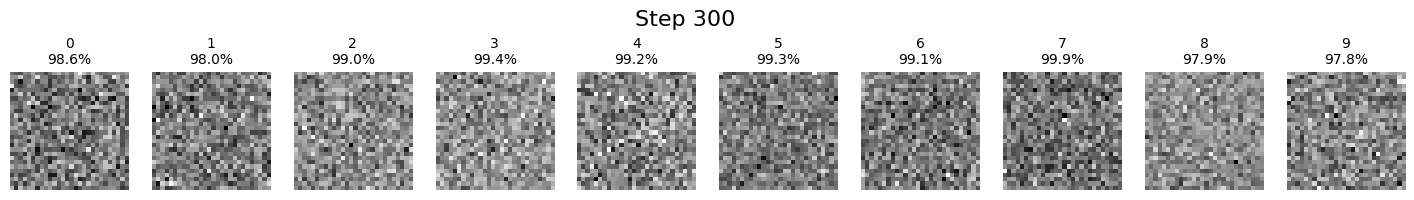

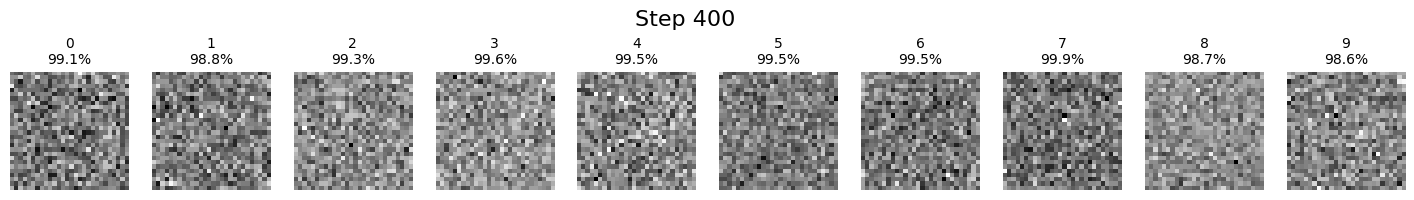

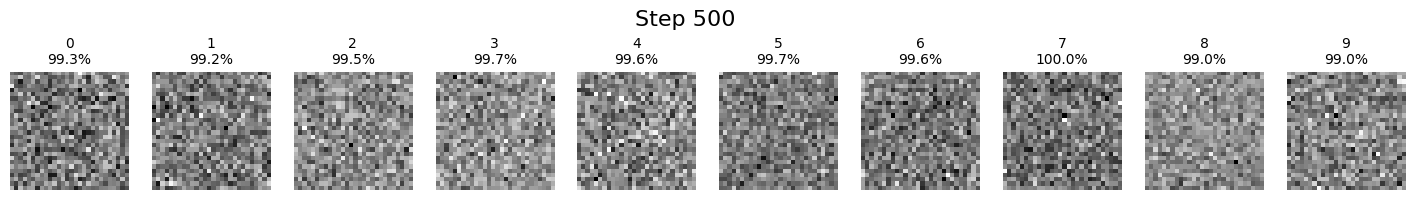

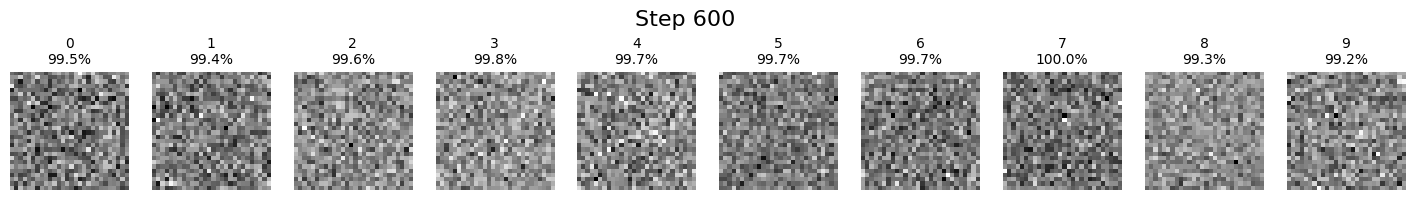

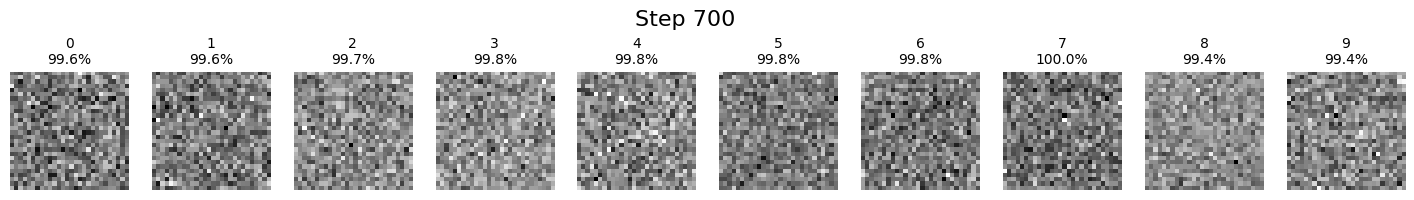

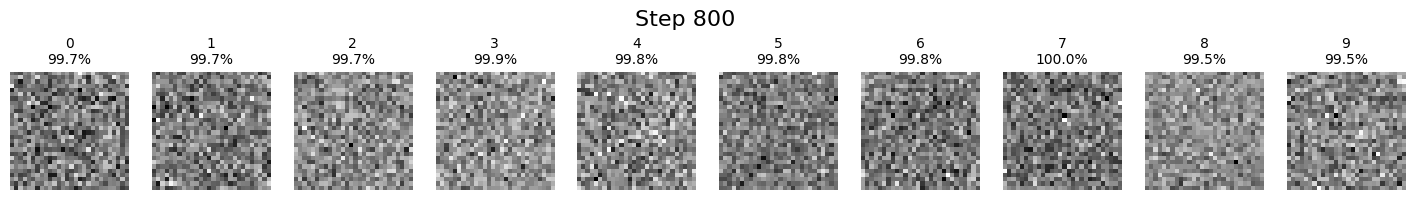

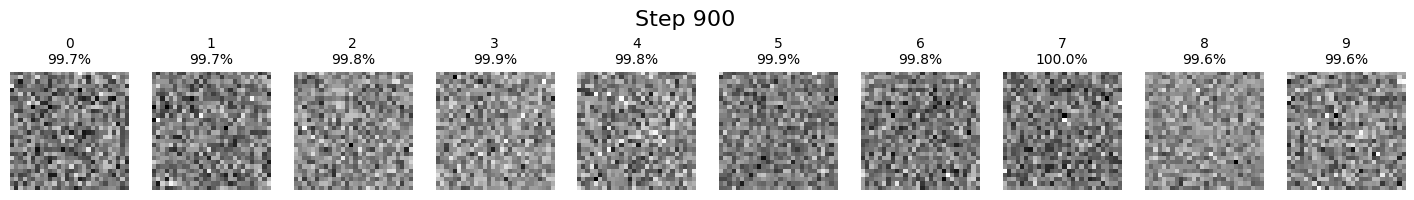

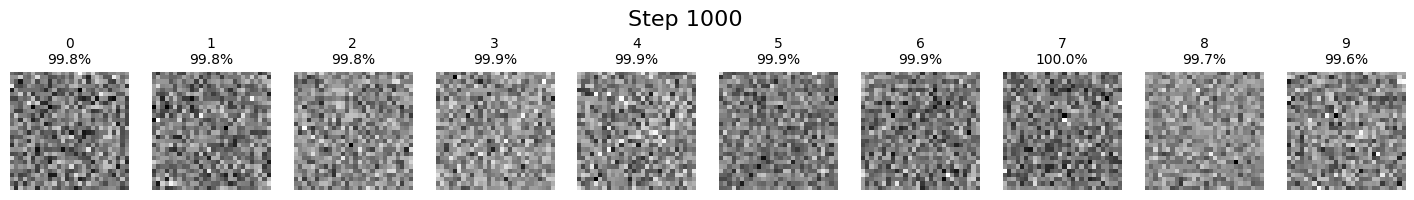

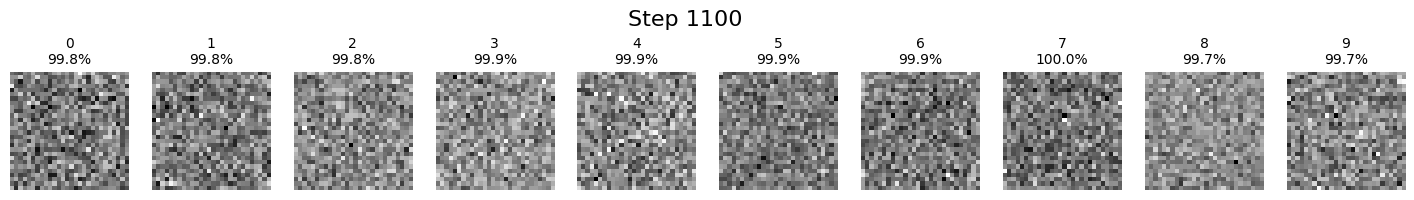

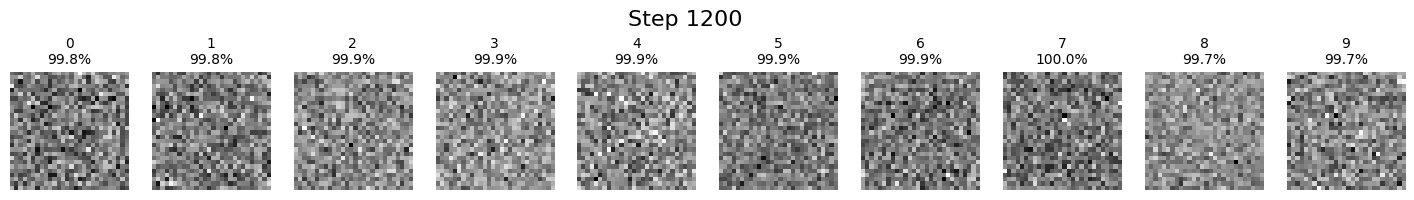

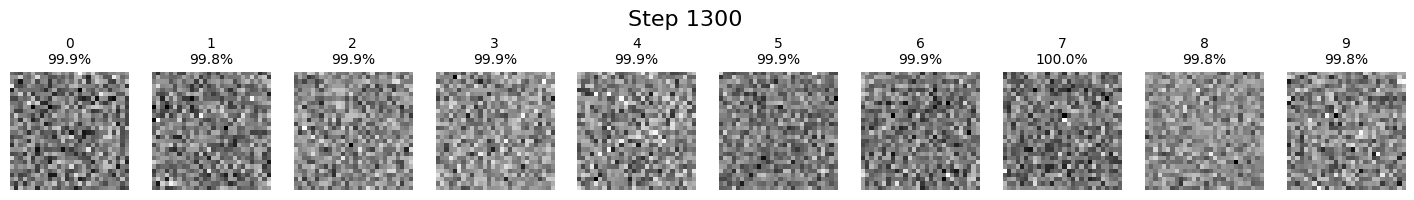

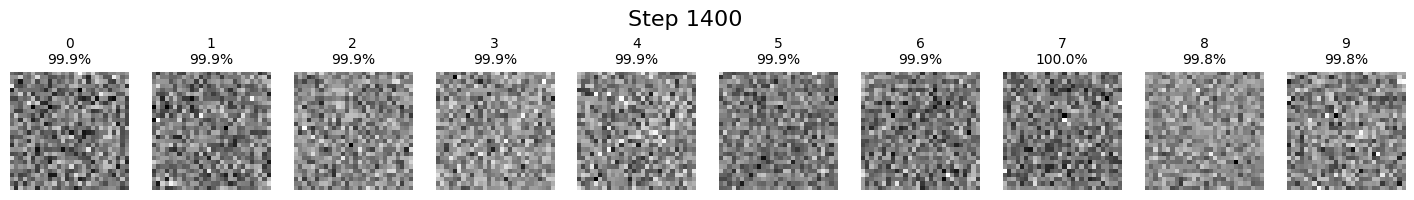

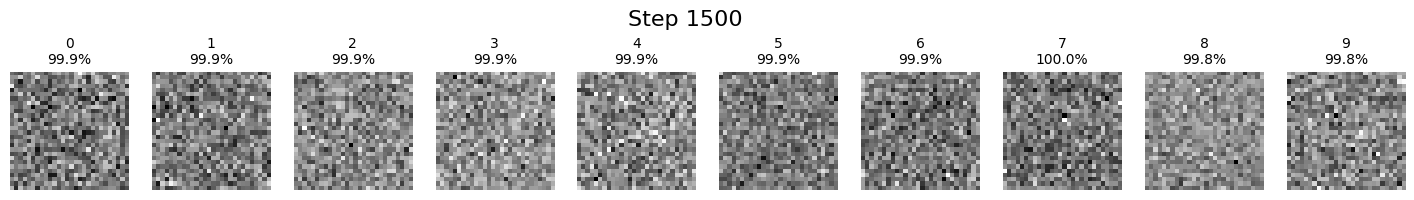

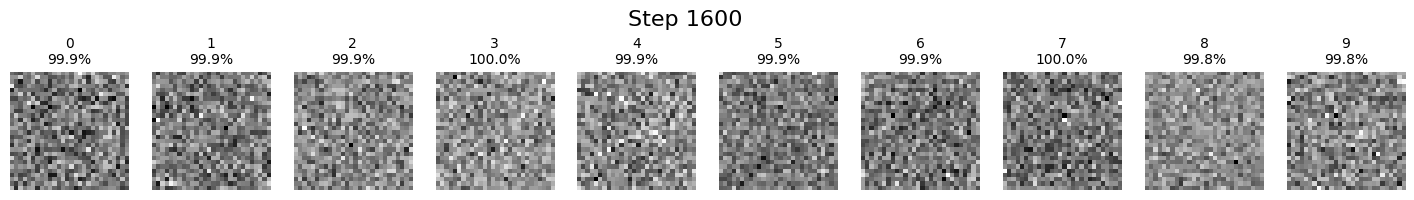

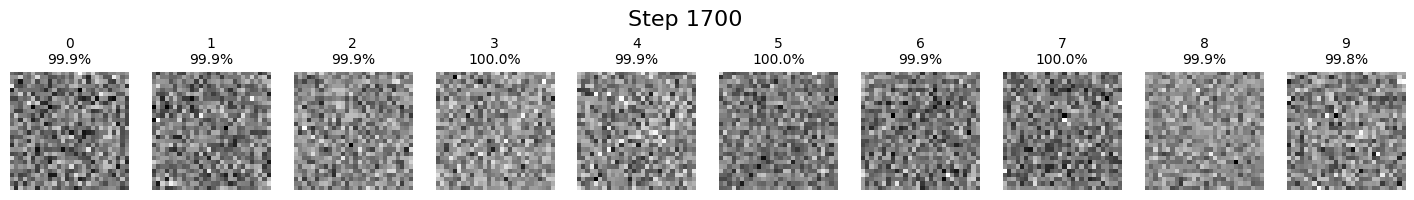

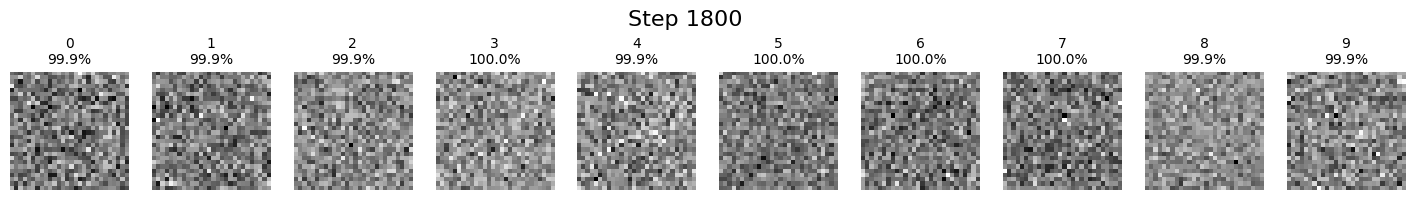

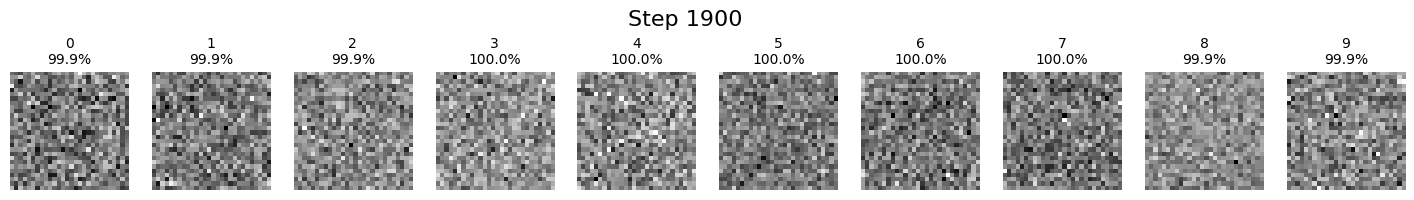

In [ ]:
# We do not want to change the parameters of the net, so we set it to eval() mode ang turn off 'requires_grad' parameters
net.eval()
for p in net.parameters():
    p.requires_grad = False

#We create 10 random noise images for the optimization process
dreams = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
targets = torch.arange(10, device=device)       #target labels

optimizer = torch.optim.Adam([dreams], lr=0.002)

evolution_task1 = []

for step in range(2000):
    optimizer.zero_grad()
    out = net(dreams)
    loss = torch.nn.functional.cross_entropy(out, targets)
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        images = dreams.detach().cpu().clone()
        logits = out.detach().cpu().clone()
        evolution_task1.append((images, logits))
        show_dreams(images, logits, step)  #statyczne podglądy


### Animation for task 1

In [ ]:
from matplotlib import animation

def animate_task1_matplotlib(evolution, interval=400):
    """
    evolution: lista elementów (images, logits),
               images: (10, 1, 28, 28), logits: (10, 10)
    """
    fig, axes = plt.subplots(1, evolution[0][0].shape[0], figsize=(18, 2.5))

    def init():
        for ax in axes:
            ax.axis("off")
        return axes

    def update(frame_idx):
        images, logits = evolution[frame_idx]
        probs = torch.nn.functional.softmax(logits, dim=1).cpu()
        preds = probs.argmax(dim=1)

        fig.suptitle(f"Frame: {frame_idx}", fontsize=16)

        for i in range(images.shape[0]):
            axes[i].clear()
            axes[i].imshow(images[i, 0], cmap="gray")
            axes[i].axis("off")

            pred_digit = preds[i].item()
            confidence = probs[i, pred_digit].item() * 100
            axes[i].set_title(f"{pred_digit}\n{confidence:.1f}%", fontsize=10)

        return axes

    anim = animation.FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=len(evolution),
        interval=interval,
        blit=False
    )
    plt.close()
    return anim


In [ ]:
from IPython.display import HTML
anim1 = animate_task1_matplotlib(evolution_task1)
HTML(anim1.to_jshtml())


## Task 2 - Perfect mixture of two digits

In the second part of the experiment, the goal is no longer to make the network classify an image as a single digit, but instead to construct an input that simultaneously activates two different output classes. To achieve this, the network’s parameters are again frozen, and only the input image is treated as a trainable variable. The optimization begins from a single (28 \times 28) noise image, and two target digits are chosen, for example 2 and 7. At every iteration, the image is passed through the network, and two separate cross‑entropy losses are computed: one that encourages the network to classify the image as the first digit, and another that encourages classification as the second. By summing these two losses, the optimization process forces the input to evolve in a direction that increases the activation of both corresponding output neurons at the same time. The gradient therefore pushes the pixel values toward a configuration that the network interprets as an optimal compromise between the two classes.

What emerges from this procedure is a compelling illustration of how neural networks internally represent categories. Although the final image still appears to a human observer as little more than structured noise, the network becomes increasingly confident that it corresponds equally well to both chosen digits. The optimization succeeds in producing an input that the model interprets as a mixture of the two classes, even though no human would recognize any meaningful structure in the result. This happens because the network is not attempting to generate a visually coherent hybrid digit. Instead, it is driven purely by the mathematical objective of maximizing the output scores for the selected classes. The resulting image therefore reflects the internal feature activations that the network associates with those digits, rather than any semantic or interpretable visual pattern.

In [ ]:
import matplotlib.pyplot as plt

def show_mixed_dream(image, logits, step):
    """
    image: tensor (1, 1, 28, 28) - po detach().cpu()
    logits: tensor (1, 10) - wyjście sieci
    step: numer iteracji
    """

    probs = torch.nn.functional.softmax(logits, dim=1).cpu()
    pred_digit = probs.argmax(dim=1).item()
    confidence = probs[0, pred_digit].item() * 100
    confidences = probs[0] * 100

    print(f"Step {step}\nPred: {pred_digit} ({confidence:.1f}%)")
    for i in range(probs.shape[1]):
        print(f"{i}: {confidences[i].item():.3}%")

    plt.figure(figsize=(3, 3))
    plt.imshow(image[0, 0], cmap="gray")
    plt.title(f"Step {step}\nPred: {pred_digit} ({confidence:.1f}%)")
    plt.axis("off")
    plt.show()


Step 0
Pred: 3 (39.3%)
0: 0.71%
1: 0.982%
2: 1.58%
3: 39.3%
4: 0.158%
5: 23.8%
6: 0.199%
7: 1.89%
8: 28.9%
9: 2.58%


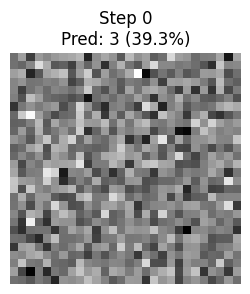

Step 250
Pred: 7 (48.8%)
0: 0.247%
1: 0.917%
2: 48.6%
3: 0.845%
4: 0.0068%
5: 0.179%
6: 0.0797%
7: 48.8%
8: 0.292%
9: 0.0158%


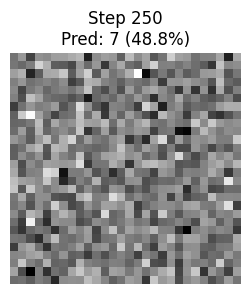

Step 500
Pred: 7 (49.5%)
0: 0.116%
1: 0.442%
2: 49.4%
3: 0.301%
4: 0.00239%
5: 0.0517%
6: 0.0364%
7: 49.5%
8: 0.0986%
9: 0.00561%


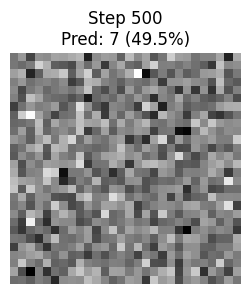

Step 750
Pred: 7 (49.7%)
0: 0.0684%
1: 0.271%
2: 49.7%
3: 0.161%
4: 0.00115%
5: 0.0233%
6: 0.0209%
7: 49.7%
8: 0.05%
9: 0.00278%


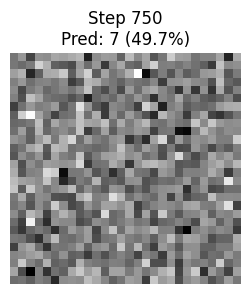

Step 1000
Pred: 7 (49.8%)
0: 0.046%
1: 0.185%
2: 49.8%
3: 0.102%
4: 0.000636%
5: 0.0128%
6: 0.0134%
7: 49.8%
8: 0.0295%
9: 0.00161%


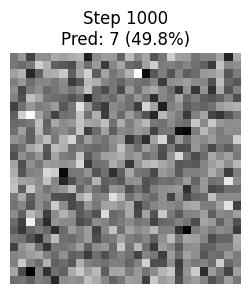

In [ ]:
# digits you want to mix
digitA = 2
digitB = 7

# start from noise
mixed = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)

optimizer = torch.optim.Adam([mixed], lr=0.002)



evolution_task2 = []

for step in range(1001):
    optimizer.zero_grad()
    out = net(mixed)
    lossA = torch.nn.functional.cross_entropy(out, torch.tensor([digitA], device=device))
    lossB = torch.nn.functional.cross_entropy(out, torch.tensor([digitB], device=device))
    loss = lossA + lossB
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        img = mixed.detach().cpu().clone()
        logits = out.detach().cpu().clone()
        evolution_task2.append((img, logits))
        if step % 250 == 0:
            show_mixed_dream(img, logits, step)



### Animation for task 2

In [ ]:
def animate_task2_matplotlib(evolution, interval=400):
    """
    evolution: lista elementów (image, logits),
               image: (1, 1, 28, 28), logits: (1, 10)
    """
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    def init():
        ax.axis("off")
        return [ax]

    def update(frame_idx):
        image, logits = evolution[frame_idx]
        probs = torch.nn.functional.softmax(logits, dim=1).cpu()
        pred_digit = probs.argmax(dim=1).item()
        confidence = probs[0, pred_digit].item() * 100

        ax.clear()
        ax.imshow(image[0, 0], cmap="gray")
        ax.set_title(f"Frame: {frame_idx}\nPred: {pred_digit} ({confidence:.1f}%)")
        ax.axis("off")

        return [ax]

    anim = animation.FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=len(evolution),
        interval=interval,
        blit=False
    )
    plt.close()
    return anim



In [ ]:
anim2 = animate_task2_matplotlib(evolution_task2)
HTML(anim2.to_jshtml())


## Task 3

### Task 1 with penalty for noise

In the final part of the experiment, an additional L2 penalty term is introduced into the loss function in order to influence the structure of the optimized input images. As before, the network’s parameters remain frozen and only the input batch is updated through gradient descent. However, the new loss function now contains not only the cross‑entropy term that encourages each image to be classified as a specific digit, but also a regularization term proportional to the mean squared value of all pixels. This additional component penalizes large pixel intensities and therefore suppresses high‑frequency noise. Conceptually, it encourages the optimization to remove any pixel variations that are not strictly necessary for increasing the network’s confidence in the target class. In effect, the L2 penalty acts as a force that pulls irrelevant or uninformative pixels toward zero, promoting smoother and more globally coherent structures.

When the penalty coefficient is small, typically below one, the optimization behaves similarly to the earlier tasks: the resulting images remain dominated by noisy, irregular patterns that do not resemble handwritten digits in any human‑interpretable sense. The network still confidently classifies them, but the visual appearance is almost indistinguishable from structured noise. As the value of the L2 coefficient increases beyond one, the influence of the regularization becomes more pronounced. The optimized images begin to exhibit larger‑scale patterns and smoother transitions, and some coarse shapes reminiscent of digit‑like structures start to emerge. Nevertheless, even for large penalty values, the images do not become true MNIST‑like digits. They remain abstract and ambiguous, lacking the clear contours and semantic features that a human observer would associate with handwritten numbers. An additional observation is the fact, that as the images are smoothed and represent more macroscopic structures, the confidence of the network in recognizing the digits gets lower.

Experiment with lambda_l2 = 0.1


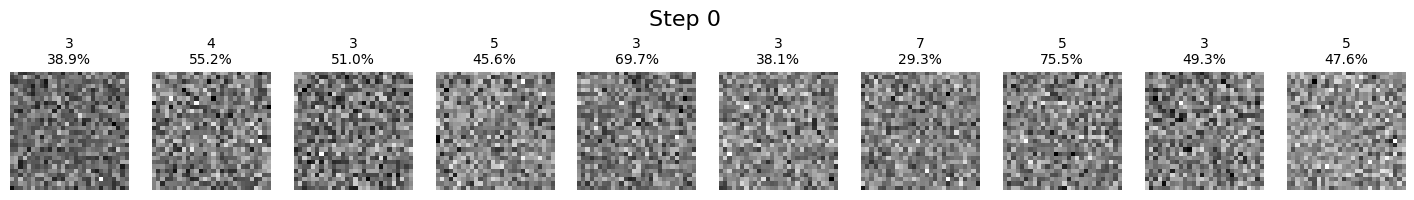

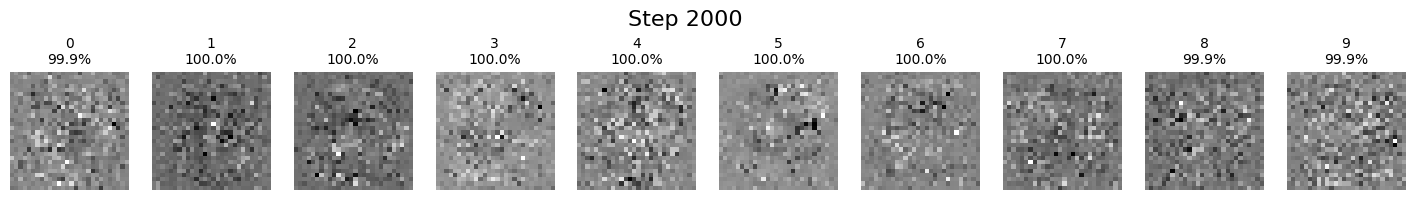

Experiment with lambda_l2 = 0.2154


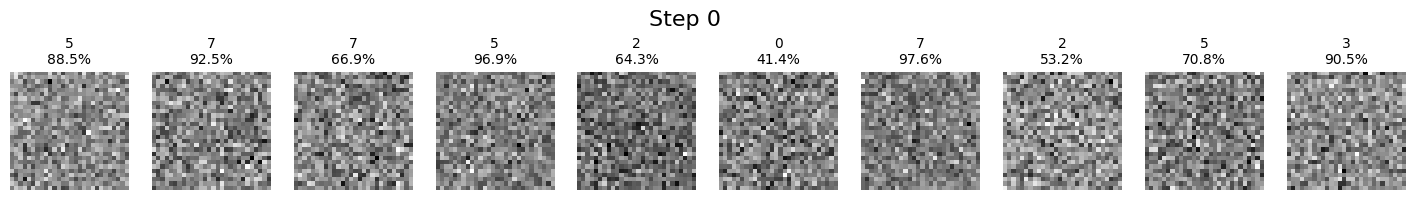

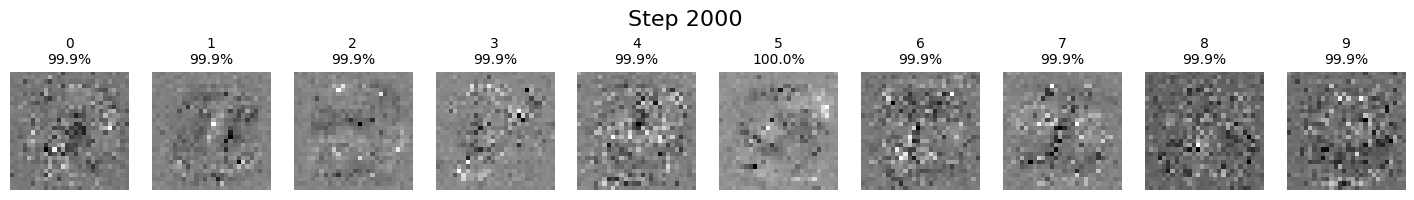

Experiment with lambda_l2 = 0.4642


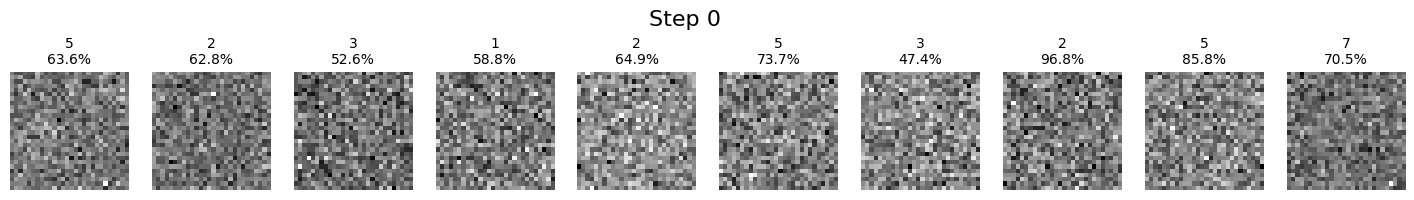

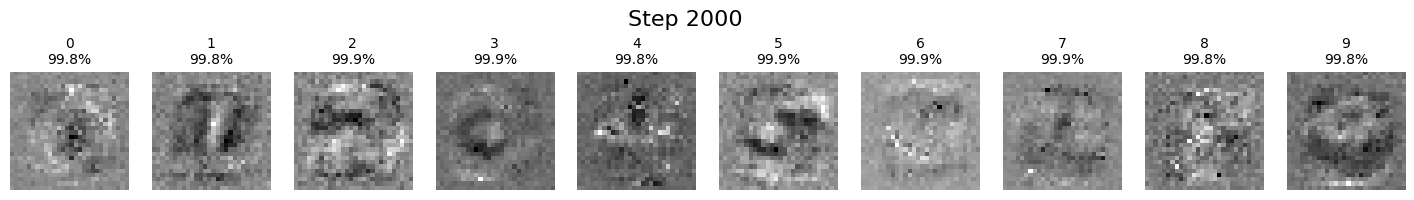

Experiment with lambda_l2 = 1.0


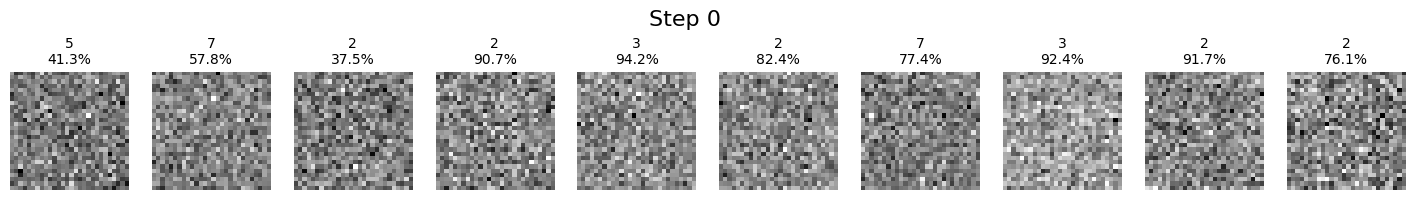

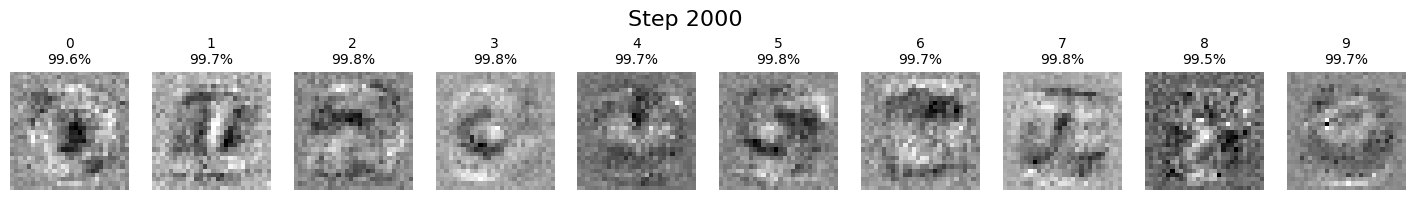

Experiment with lambda_l2 = 2.154


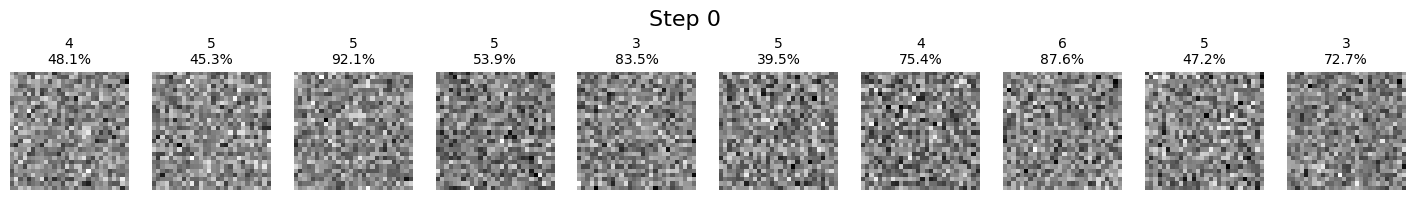

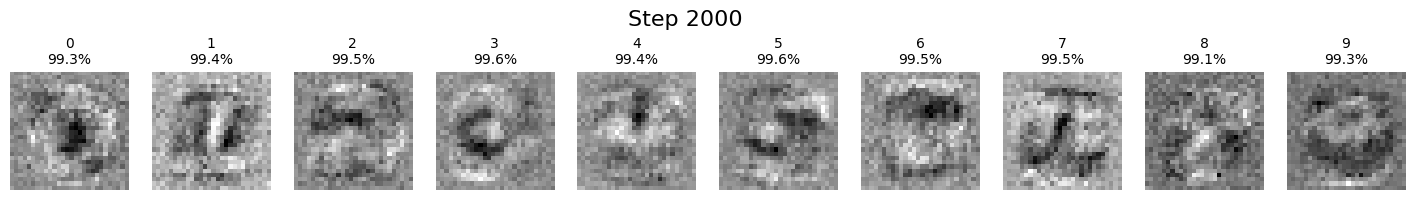

Experiment with lambda_l2 = 4.642


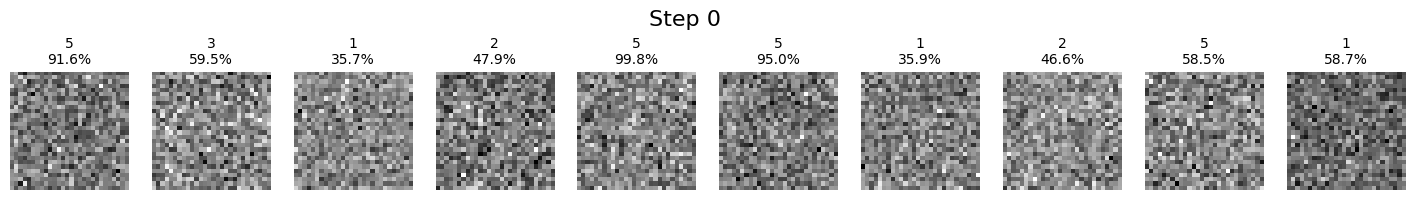

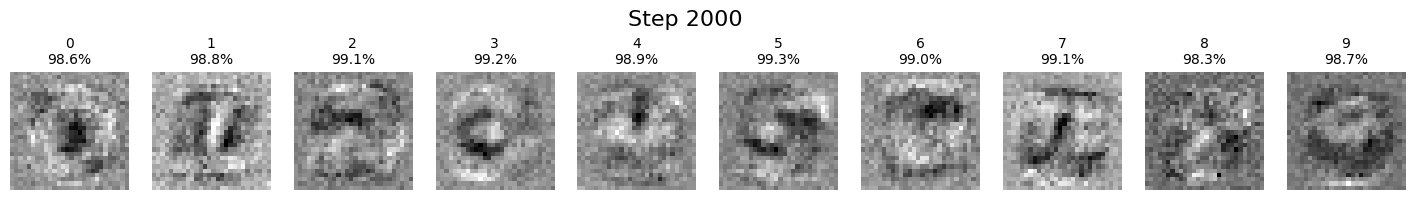

Experiment with lambda_l2 = 10.0


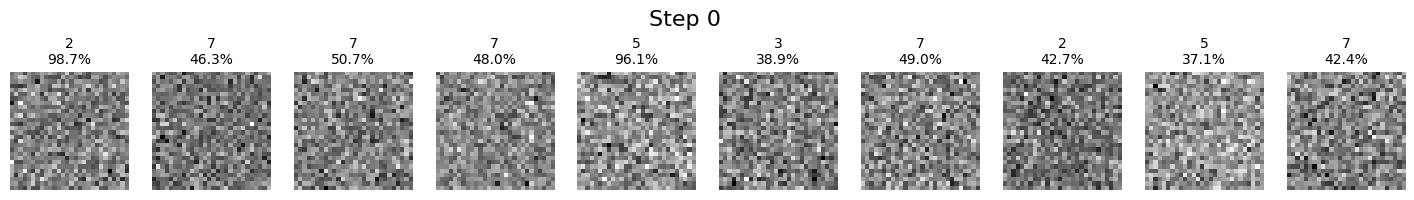

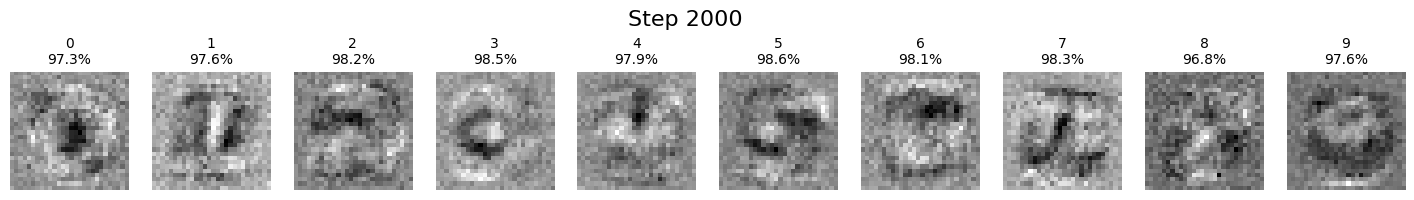

Experiment with lambda_l2 = 21.54


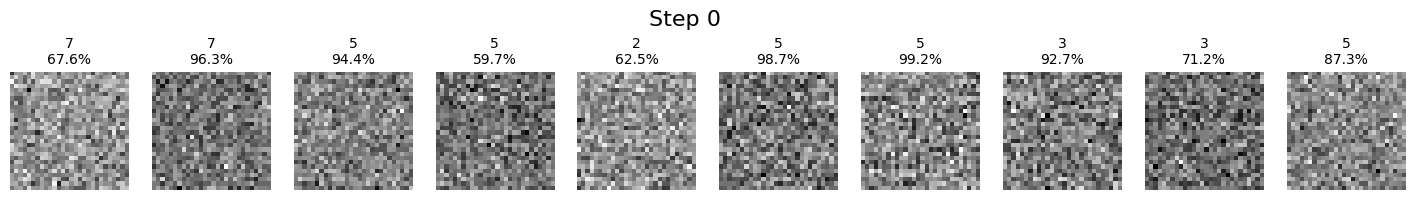

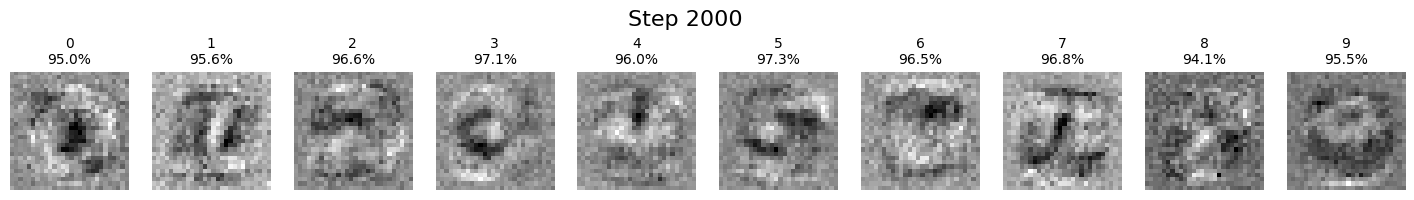

Experiment with lambda_l2 = 46.42


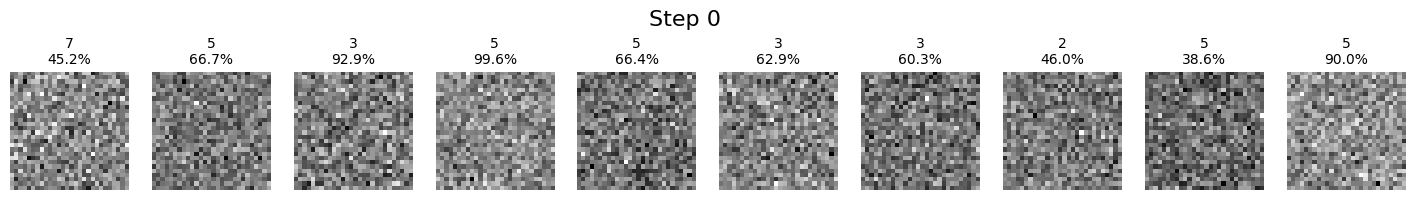

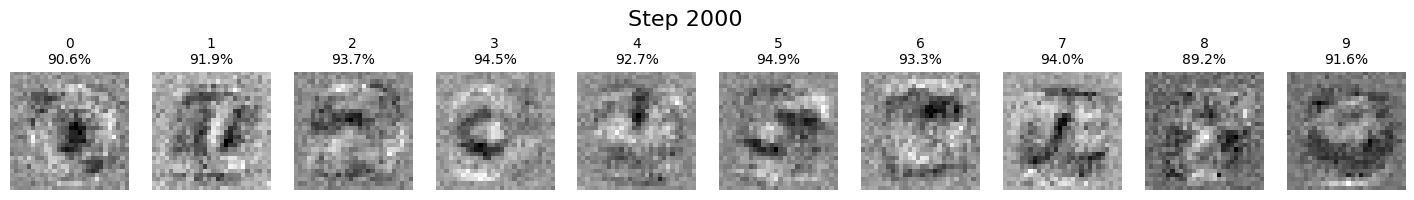

Experiment with lambda_l2 = 100.0


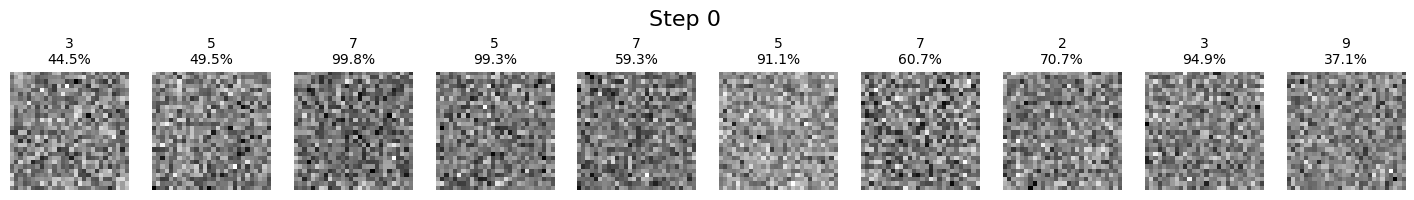

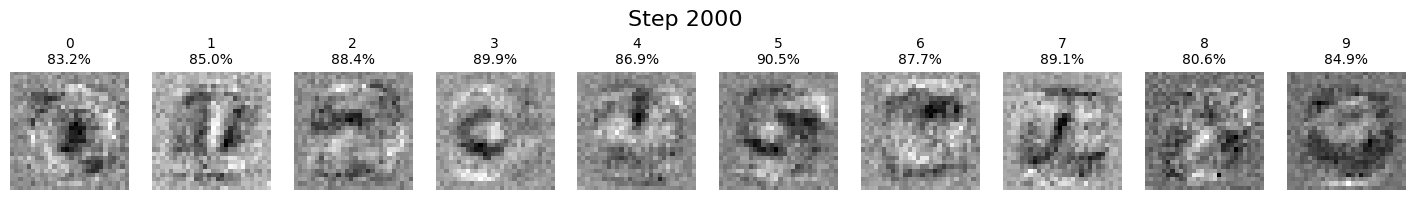

In [ ]:
import numpy as np
#lambda_l2 * dreamed_input_batch.pow(2).mean()

def task1_witl_l2_penalty(lambda_l2):
    # We do not want to change the parameters of the net, so we set it to eval() mode ang turn off 'requires_grad' parameters
    net.eval()
    for p in net.parameters():
        p.requires_grad = False

    #We create 10 random noise images for the optimization process
    dreams = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
    targets = torch.arange(10, device=device)       #target labels

    optimizer = torch.optim.Adam([dreams], lr=0.01)

    print(rf"Experiment with lambda_l2 = {lambda_l2:.4}")
    for step in range(2001):
        optimizer.zero_grad()
        out = net(dreams)
        loss = torch.nn.functional.cross_entropy(out, targets) + lambda_l2 * dreams.pow(2).mean()
        loss.backward()
        optimizer.step()

        if step % 2000 == 0:
            plot_images = dreams.detach().cpu().clone()
            plot_logits = out.detach().cpu().clone()
            show_dreams(plot_images, plot_logits, step)

penalties = np.geomspace(0.1, 100, 10)
for penalty in penalties:
    task1_witl_l2_penalty(penalty)


### Task 2 with penalty for noise

In the extended version of the second task, the goal remains to construct a single input image that the network interprets as belonging simultaneously to two different digit classes. As before, the network’s parameters are frozen and only the input image is optimized. The loss function contains two cross‑entropy terms, one encouraging the image to be classified as the first chosen digit and the other encouraging classification as the second. To this objective, an additional L2 penalty is added, proportional to the mean squared value of all pixels, which suppresses unnecessary pixel intensities and discourages the optimization from relying on high‑frequency noise patterns. Conceptually, the L2 penalty acts as a smoothing force: it pushes irrelevant pixel values toward zero and encourages the optimization to find a cleaner, more globally coherent configuration that still activates the two target classes.

The behavior observed during optimization mirrors the results from the first task. When the penalty coefficient is small, the generated image remains dominated by noisy, irregular structures that do not resemble any recognizable mixture of digits to a human observer. The network, however, confidently interprets the image as belonging equally to both selected classes, demonstrating once again that its internal representation of digits is based on abstract statistical cues rather than human‑interpretable shapes. As the L2 coefficient increases, the influence of the regularization becomes more pronounced. The optimized image begins to exhibit smoother, larger-scale patterns, and some coarse structures start to emerge. Nevertheless, even at high penalty values, the resulting image does not become a meaningful hybrid digit in the human sense. It remains visually ambiguous and abstract, lacking the clear contours or semantic features that humans rely on when recognizing handwritten numbers.

An additional effect of increasing the regularization strength is a gradual reduction in the network’s confidence. As the penalty grows, the optimization is forced to suppress more and more pixel variation, limiting the model’s ability to exploit the fine‑grained patterns that strongly activate its internal features. The network therefore becomes less certain in assigning the image to either of the two target classes. This trade‑off between smoothness and classification confidence illustrates the tension between human‑interpretable structure and the mathematical representations learned by neural networks. Even when the optimization is constrained to produce cleaner images, the resulting patterns remain far removed from the shapes that humans would identify as digits.

Experiment with lambda_l2 = 0.1
Step 0
Pred: 7 (71.2%)
0: 0.0401%
1: 7.83%
2: 1.15%
3: 14.6%
4: 0.196%
5: 4.91%
6: 0.0372%
7: 71.2%
8: 0.0213%
9: 0.0333%


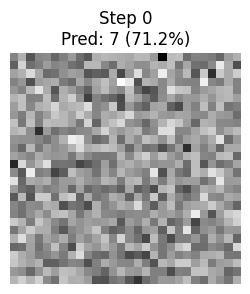

Step 1000
Pred: 3 (50.0%)
0: 0.00262%
1: 0.0125%
2: 0.0352%
3: 50.0%
4: 0.00834%
5: 0.0232%
6: 0.00352%
7: 0.00522%
8: 49.9%
9: 0.0187%


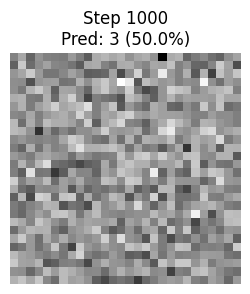

Experiment with lambda_l2 = 0.2154
Step 0
Pred: 7 (80.1%)
0: 0.452%
1: 0.872%
2: 0.231%
3: 1.1%
4: 0.00805%
5: 16.9%
6: 0.026%
7: 80.1%
8: 0.00871%
9: 0.29%


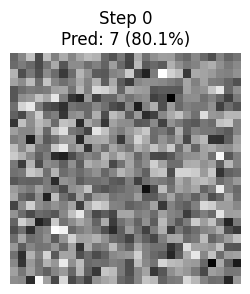

Step 1000
Pred: 3 (49.9%)
0: 0.00487%
1: 0.0132%
2: 0.0662%
3: 49.9%
4: 0.0065%
5: 0.032%
6: 0.00181%
7: 0.00359%
8: 49.9%
9: 0.0394%


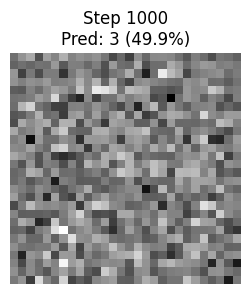

Experiment with lambda_l2 = 0.4642
Step 0
Pred: 6 (34.8%)
0: 17.1%
1: 3.43%
2: 7.84%
3: 0.871%
4: 0.297%
5: 16.6%
6: 34.8%
7: 1.18%
8: 4.43%
9: 13.5%


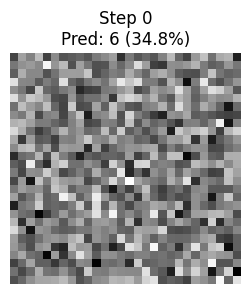

Step 1000
Pred: 3 (49.9%)
0: 0.0105%
1: 0.0409%
2: 0.0657%
3: 49.9%
4: 0.0229%
5: 0.0466%
6: 0.0145%
7: 0.0133%
8: 49.9%
9: 0.0524%


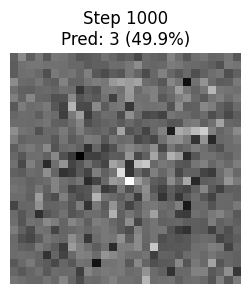

Experiment with lambda_l2 = 1.0
Step 0
Pred: 3 (58.1%)
0: 0.0478%
1: 0.0994%
2: 0.106%
3: 58.1%
4: 0.00559%
5: 41.4%
6: 0.0596%
7: 0.151%
8: 0.0147%
9: 0.0385%


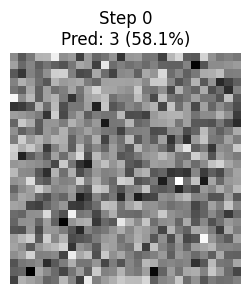

Step 1000
Pred: 3 (49.8%)
0: 0.0176%
1: 0.0445%
2: 0.144%
3: 49.8%
4: 0.0425%
5: 0.0913%
6: 0.0274%
7: 0.0179%
8: 49.7%
9: 0.101%


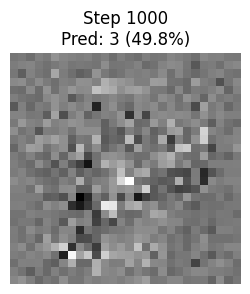

Experiment with lambda_l2 = 2.154
Step 0
Pred: 3 (55.8%)
0: 0.144%
1: 2.3%
2: 17.3%
3: 55.8%
4: 0.0195%
5: 5.61%
6: 0.173%
7: 18.5%
8: 0.149%
9: 0.0379%


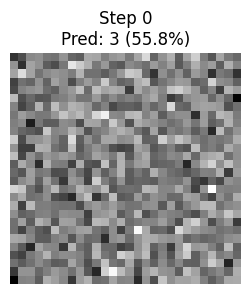

Step 1000
Pred: 3 (49.7%)
0: 0.0356%
1: 0.0982%
2: 0.219%
3: 49.7%
4: 0.0718%
5: 0.14%
6: 0.0435%
7: 0.052%
8: 49.5%
9: 0.16%


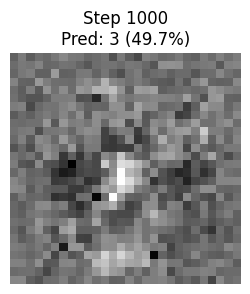

Experiment with lambda_l2 = 4.642
Step 0
Pred: 2 (52.5%)
0: 0.363%
1: 33.6%
2: 52.5%
3: 3.41%
4: 0.14%
5: 1.11%
6: 0.411%
7: 2.06%
8: 6.04%
9: 0.365%


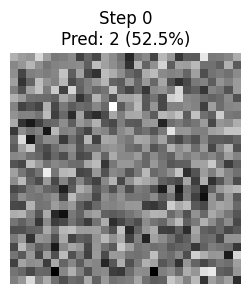

Step 1000
Pred: 3 (49.3%)
0: 0.0874%
1: 0.198%
2: 0.382%
3: 49.3%
4: 0.134%
5: 0.269%
6: 0.0921%
7: 0.094%
8: 49.1%
9: 0.293%


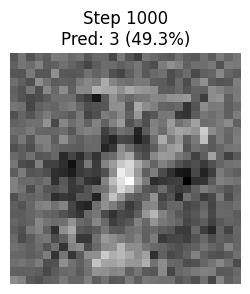

Experiment with lambda_l2 = 10.0
Step 0
Pred: 2 (61.7%)
0: 4.5%
1: 0.711%
2: 61.7%
3: 19.2%
4: 0.139%
5: 3.73%
6: 1.04%
7: 1.16%
8: 7.74%
9: 0.0703%


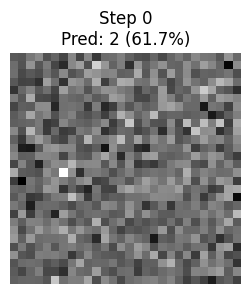

Step 1000
Pred: 3 (49.2%)
0: 0.175%
1: 0.359%
2: 0.696%
3: 49.2%
4: 0.256%
5: 0.483%
6: 0.191%
7: 0.193%
8: 47.9%
9: 0.548%


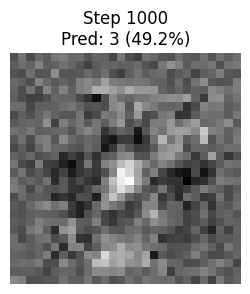

Experiment with lambda_l2 = 21.54
Step 0
Pred: 4 (56.4%)
0: 0.0125%
1: 3.62%
2: 0.0292%
3: 22.0%
4: 56.4%
5: 7.3%
6: 0.0486%
7: 2.86%
8: 0.173%
9: 7.54%


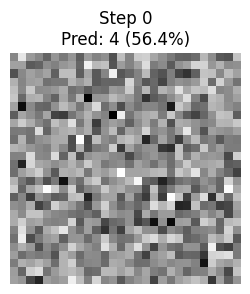

Step 1000
Pred: 3 (47.7%)
0: 0.352%
1: 0.664%
2: 1.24%
3: 47.7%
4: 0.534%
5: 0.854%
6: 0.385%
7: 0.397%
8: 46.9%
9: 0.945%


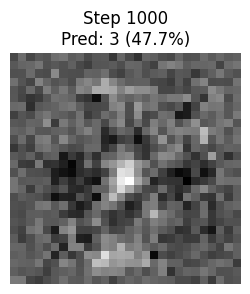

Experiment with lambda_l2 = 46.42
Step 0
Pred: 2 (87.9%)
0: 0.091%
1: 0.674%
2: 87.9%
3: 7.96%
4: 0.00214%
5: 0.249%
6: 0.0276%
7: 2.98%
8: 0.123%
9: 0.0133%


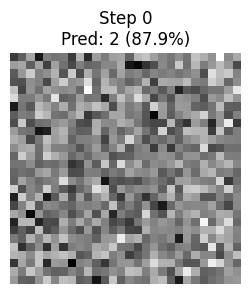

Step 1000
Pred: 3 (45.9%)
0: 0.712%
1: 1.22%
2: 2.15%
3: 45.9%
4: 0.967%
5: 1.49%
6: 0.762%
7: 0.762%
8: 44.5%
9: 1.59%


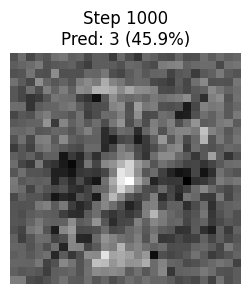

Experiment with lambda_l2 = 100.0
Step 0
Pred: 5 (99.4%)
0: 0.00265%
1: 0.369%
2: 0.0364%
3: 0.031%
4: 0.00642%
5: 99.4%
6: 0.0629%
7: 0.0677%
8: 0.00145%
9: 0.00102%


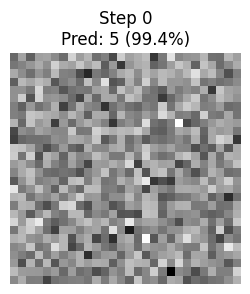

Step 1000
Pred: 3 (43.1%)
0: 1.33%
1: 2.11%
2: 3.29%
3: 43.1%
4: 1.81%
5: 2.5%
6: 1.42%
7: 1.47%
8: 40.2%
9: 2.8%


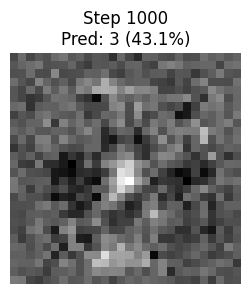

In [ ]:
def task2_witl_l2_penalty(lambda_l2, digitA, digitB):
    # start from noise
    mixed = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([mixed], lr=0.01)

    print(rf"Experiment with lambda_l2 = {lambda_l2:.4}")
    for step in range(1001):
        optimizer.zero_grad()

        out = net(mixed)  # shape (1, 10)

        # loss = CE(out, A) + CE(out, B) + lambda_l2 * dreams.pow(2).mean()
        lossA = torch.nn.functional.cross_entropy(out, torch.tensor([digitA], device=device))
        lossB = torch.nn.functional.cross_entropy(out, torch.tensor([digitB], device=device))
        loss = lossA + lossB + lambda_l2 * mixed.pow(2).mean()

        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            img = mixed.detach().cpu().clone()
            logits = out.detach().cpu().clone()
            show_mixed_dream(img, logits, step)

penalties = np.geomspace(0.1, 100, 10)
for penalty in penalties:
    task2_witl_l2_penalty(penalty, digitA=3, digitB=8)
